# LP1 EEG Noise-Removal Pipeline

1. exact dataset description and justification
2. raw EEG inspection
3. basic preprocessing: band-pass filtering + 50 Hz notch filtering + common-average re-referencing
4. controlled synthetic artifact examples:
   - eye-blink-like artifact
   - muscle-noise-like artifact
   - flat channel
   - noisy bad channel
5. **global bad-channel detection** using per-channel metrics
6. **epoch-wise bad-channel / bad-epoch detection** using metrics per channel and per epoch
7. interpolation of persistent structural bad channels
8. ICA demonstration for blink-like artifact removal
9. final pipeline report and output figures


## 0. Imports and Configuration


In [ ]:
from pathlib import Path
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt
import mne

INPUT_FILE = Path("data/S001R01.edf")
OUTPUT_DIR = Path("results_replacement_epochwise")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

L_FREQ = 1.0
H_FREQ = 40.0
NOTCH_FREQ = 50.0
EPOCH_LENGTH = 2.0 

print("MNE version:", mne.__version__)
print("Current working directory:", Path.cwd())
print("Input file:", INPUT_FILE)
print("Input file exists:", INPUT_FILE.exists())
print("Output directory:", OUTPUT_DIR)

MNE version: 1.12.1
Current working directory: d:\Codes\Python\lp1_eeg_noise_removal_pipeline
Input file: data\S001R01.edf
Input file exists: True
Output directory: results_replacement_epochwise


## 1. Dataset Description

The EEG file used here is `S001R01.edf` from the **PhysioNet EEG Motor Movement/Imagery Dataset**, also known as EEGMMIDB.

- `S001` means **Subject 1**
- `R01` means **Run 1**
- Run 1 is a **baseline eyes-open recording**
- The file contains **64 EEG channels**
- Sampling frequency is **160 Hz**
- Duration is approximately **61 seconds**

### Reason for choosing

This file was chosen because it is public, small enough for an LP1 demonstration, compatible with MNE-Python, and contains realistic multichannel EEG.

### Important limitation

This exact baseline file does **not** contain labeled eye-blink, muscle, or bad-channel artifacts. Therefore, controlled synthetic artifacts are added later to demonstrate artifact-removal concepts clearly.

## 2. Load EEG Data

In [2]:
def load_eeg(input_path: Path):
    suffix = input_path.suffix.lower()
    if suffix == ".edf":
        raw = mne.io.read_raw_edf(input_path, preload=True, verbose=False)
    elif suffix == ".bdf":
        raw = mne.io.read_raw_bdf(input_path, preload=True, verbose=False)
    elif suffix == ".set":
        raw = mne.io.read_raw_eeglab(input_path, preload=True, verbose=False)
    elif suffix == ".fif":
        raw = mne.io.read_raw_fif(input_path, preload=True, verbose=False)
    elif suffix == ".vhdr":
        raw = mne.io.read_raw_brainvision(input_path, preload=True, verbose=False)
    else:
        raise ValueError(f"Unsupported EEG format: {suffix}")

    unknown = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ == "misc"]
    if unknown:
        raw.set_channel_types({ch: "eeg" for ch in unknown})
    return raw

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {INPUT_FILE}. Put S001R01.edf inside the data/ folder."
    )

raw = load_eeg(INPUT_FILE)
raw_original = raw.copy()

metadata = {
    "input_file": str(INPUT_FILE),
    "source_dataset": "PhysioNet EEG Motor Movement/Imagery Dataset / EEGMMIDB",
    "exact_experiment": "Subject 1, Run 1: baseline eyes-open recording",
    "n_channels": len(raw.ch_names),
    "channel_types": sorted(set(raw.get_channel_types())),
    "sampling_frequency_hz": float(raw.info["sfreq"]),
    "duration_seconds": float(raw.times[-1]),
    "first_10_channels": raw.ch_names[:10],
}

with open(OUTPUT_DIR / "metadata_replacement_epochwise.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

metadata

{'input_file': 'data\\S001R01.edf',
 'source_dataset': 'PhysioNet EEG Motor Movement/Imagery Dataset / EEGMMIDB',
 'exact_experiment': 'Subject 1, Run 1: baseline eyes-open recording',
 'n_channels': 64,
 'channel_types': ['eeg'],
 'sampling_frequency_hz': 160.0,
 'duration_seconds': 60.99375,
 'first_10_channels': ['Fc5.',
  'Fc3.',
  'Fc1.',
  'Fcz.',
  'Fc2.',
  'Fc4.',
  'Fc6.',
  'C5..',
  'C3..',
  'C1..']}

## 3. Plotting Helper Functions

In [3]:
def plot_time_segment(raw_obj, title, filename, picks=None, duration=10.0, start=0.0):
    if picks is None:
        eeg_picks = mne.pick_types(raw_obj.info, eeg=True, eog=False, ecg=False, exclude=[])
        picks = eeg_picks[:min(8, len(eeg_picks))]
    else:
        picks = [raw_obj.ch_names.index(ch) if isinstance(ch, str) else ch for ch in picks]

    if len(picks) == 0:
        print("No channels selected for plotting.")
        return None

    sfreq = raw_obj.info["sfreq"]
    start_samp = int(start * sfreq)
    stop_samp = int(min((start + duration) * sfreq, raw_obj.n_times))
    data, times = raw_obj[picks, start_samp:stop_samp]
    data_uv = data * 1e6
    times = times - times[0]

    plt.figure(figsize=(12, 5))
    spacing = np.nanstd(data_uv) * 6 if np.nanstd(data_uv) > 0 else 50
    offset = 0
    for i, ch_data in enumerate(data_uv):
        plt.plot(times, ch_data + offset, linewidth=0.8, label=raw_obj.ch_names[picks[i]])
        offset += spacing

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude + offset (µV)")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=200)
    plt.show()
    return path


def plot_psd(raw_obj, title, filename, fmax=80):
    picks = mne.pick_types(raw_obj.info, eeg=True, eog=False, ecg=False, exclude=[])
    fmax = min(fmax, raw_obj.info["sfreq"] / 2 - 1)
    psd = raw_obj.compute_psd(picks=picks, fmin=0.5, fmax=fmax, verbose=False)
    values, freqs = psd.get_data(return_freqs=True)

    plt.figure(figsize=(10, 5))
    plt.semilogy(freqs, values.mean(axis=0))
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power spectral density")
    plt.tight_layout()
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=200)
    plt.show()
    return path


def plot_psd_comparison(raw_a, raw_b, label_a, label_b, title, filename, fmax=80):
    picks = mne.pick_types(raw_a.info, eeg=True, eog=False, ecg=False, exclude=[])
    fmax = min(fmax, raw_a.info["sfreq"] / 2 - 1)

    psd_a = raw_a.compute_psd(picks=picks, fmin=0.5, fmax=fmax, verbose=False)
    psd_b = raw_b.compute_psd(picks=picks, fmin=0.5, fmax=fmax, verbose=False)
    a, freqs = psd_a.get_data(return_freqs=True)
    b, freqs_b = psd_b.get_data(return_freqs=True)

    plt.figure(figsize=(10, 5))
    plt.semilogy(freqs, a.mean(axis=0), label=label_a)
    plt.semilogy(freqs_b, b.mean(axis=0), label=label_b)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power spectral density")
    plt.legend()
    plt.tight_layout()
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=200)
    plt.show()
    return path

## 4. Raw Data Inspection


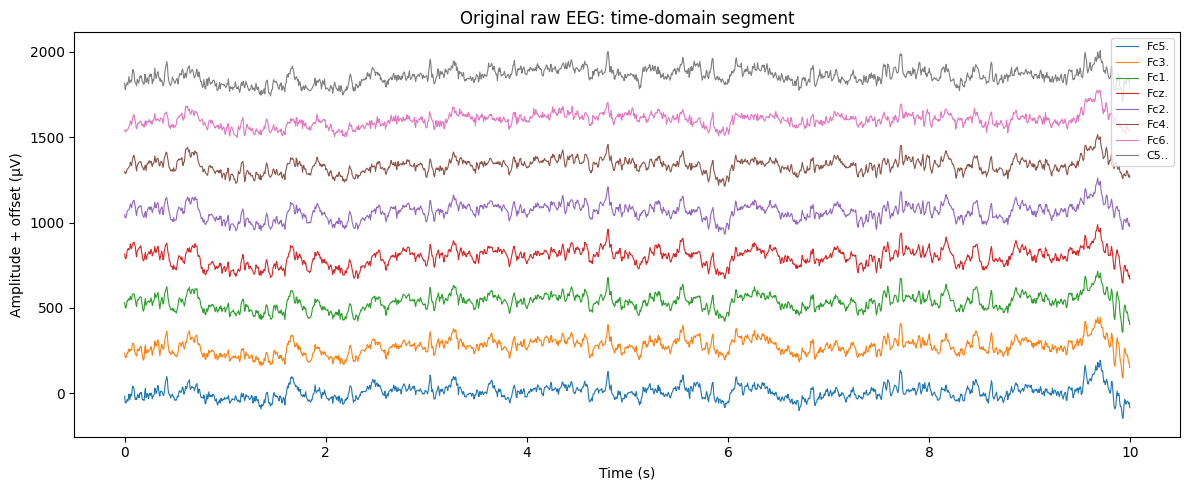

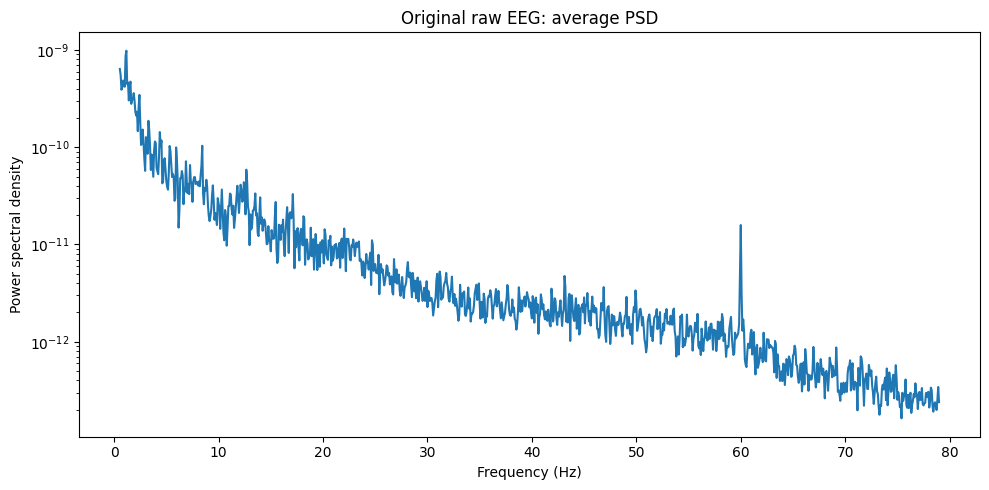

WindowsPath('results_replacement_epochwise/02_original_raw_psd.png')

In [4]:
plot_time_segment(raw, "Original raw EEG: time-domain segment", "01_original_raw_time.png")
plot_psd(raw, "Original raw EEG: average PSD", "02_original_raw_psd.png")

## 5. Basic Preprocessing: Filtering, Notch Filtering, and Common Average Re-Referencing


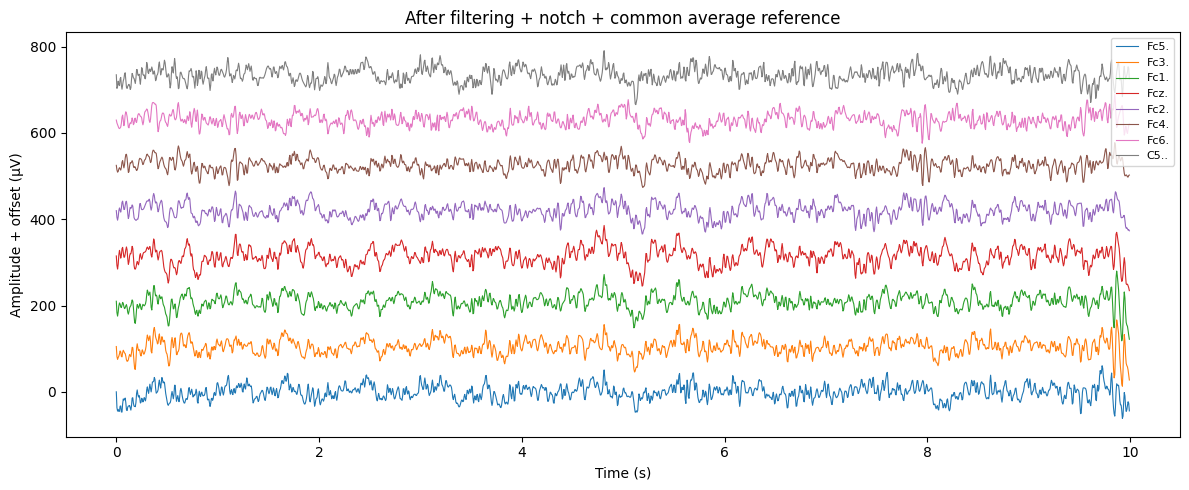

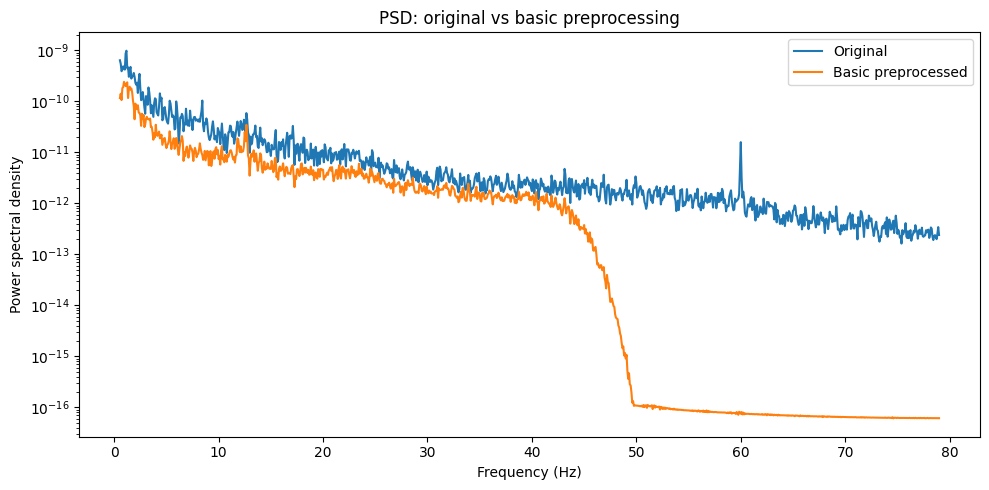

WindowsPath('results_replacement_epochwise/04_original_vs_basic_psd.png')

In [5]:
raw_basic = raw.copy()
raw_basic.filter(l_freq=L_FREQ, h_freq=H_FREQ, picks="eeg", verbose=False)
raw_basic.notch_filter(freqs=[NOTCH_FREQ], picks="eeg", verbose=False)
raw_basic.set_eeg_reference("average", projection=False, verbose=False)

plot_time_segment(raw_basic, "After filtering + notch + common average reference", "03_basic_preprocessed_time.png")
plot_psd_comparison(raw, raw_basic, "Original", "Basic preprocessed", "PSD: original vs basic preprocessing", "04_original_vs_basic_psd.png")

## 6. Synthetic Artifact Demonstration

Because `S001R01.edf` is a baseline eyes-open file without labeled artifacts, controlled synthetic artifacts are added to demonstrate preprocessing concepts.

Synthetic examples:

 - eye-blink-like artifact in frontal channels
 - muscle-noise-like artifact in temporal channels
 - one flat channel
 - one noisy bad channel

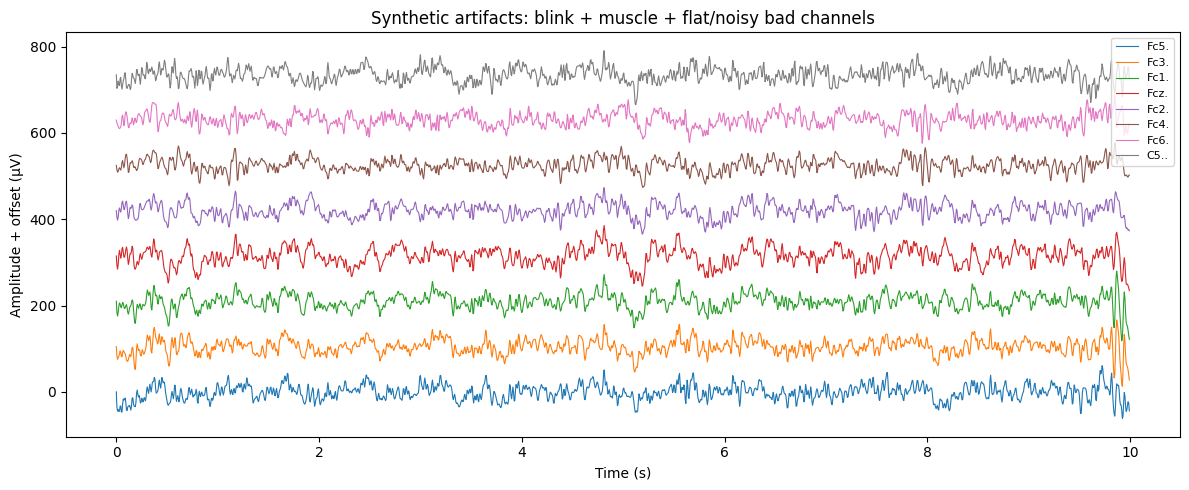

C:\Users\Soroush\AppData\Local\Temp\ipykernel_15988\3862764594.py:61: UserWarning: Zero value in spectrum for channel Pz..
  psd_b = raw_b.compute_psd(picks=picks, fmin=0.5, fmax=fmax, verbose=False)


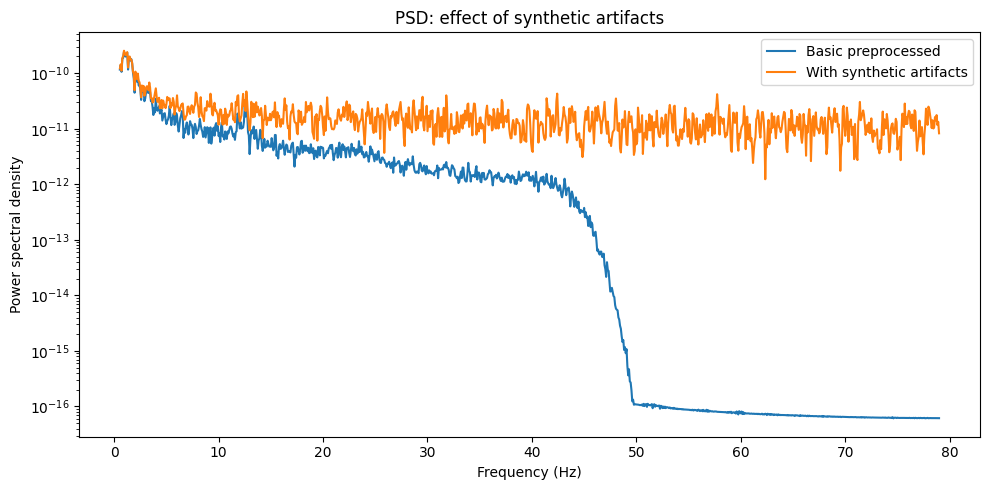

WindowsPath('results_replacement_epochwise/06_synthetic_artifacts_psd.png')

In [6]:
def add_synthetic_blink(raw_obj, channels=("Fp1.", "Fpz.", "Fp2."), onset=10.0, duration=1.0, amplitude_uv=180.0):
    out = raw_obj.copy()
    times = out.times
    center = onset + duration / 2
    sigma = duration / 6
    blink = amplitude_uv * 1e-6 * np.exp(-0.5 * ((times - center) / sigma) ** 2)
    for ch in channels:
        if ch in out.ch_names:
            out._data[out.ch_names.index(ch), :] += blink
    return out


def add_synthetic_muscle(raw_obj, channels=("T7..", "T8..", "Ft7.", "Ft8."), start=20.0, duration=5.0, amplitude_uv=35.0, seed=7):
    rng = np.random.default_rng(seed)
    out = raw_obj.copy()
    sfreq = out.info["sfreq"]
    start_i = int(start * sfreq)
    stop_i = int((start + duration) * sfreq)
    n = stop_i - start_i
    noise = rng.normal(size=n)
    kernel = np.ones(9) / 9
    smooth = np.convolve(noise, kernel, mode="same")
    burst = noise - smooth
    burst = burst / np.std(burst) * amplitude_uv * 1e-6
    for ch in channels:
        if ch in out.ch_names:
            out._data[out.ch_names.index(ch), start_i:stop_i] += burst
    return out


def add_synthetic_bad_channels(raw_obj, flat_ch="Pz..", noisy_ch="O1..", noise_uv=250.0, seed=13):
    rng = np.random.default_rng(seed)
    out = raw_obj.copy()
    if flat_ch in out.ch_names:
        out._data[out.ch_names.index(flat_ch), :] = 0.0
    if noisy_ch in out.ch_names:
        idx = out.ch_names.index(noisy_ch)
        out._data[idx, :] += rng.normal(scale=noise_uv * 1e-6, size=out.n_times)
    return out

raw_artifact = raw_basic.copy()
raw_artifact = add_synthetic_blink(raw_artifact)
raw_artifact = add_synthetic_muscle(raw_artifact)
raw_artifact = add_synthetic_bad_channels(raw_artifact)

plot_time_segment(raw_artifact, "Synthetic artifacts: blink + muscle + flat/noisy bad channels", "05_synthetic_artifacts_time.png")
plot_psd_comparison(raw_basic, raw_artifact, "Basic preprocessed", "With synthetic artifacts", "PSD: effect of synthetic artifacts", "06_synthetic_artifacts_psd.png")

## 7. Global Bad-Channel Detection Metrics

This section detects suspicious channels across the **whole recording**.

Metrics used:

1. **Standard deviation**: very high means noisy; very low means flat.
2. **Peak-to-peak amplitude**: very high means abnormal large fluctuations.
3. **Mean correlation with other channels**: very low means the channel behaves unlike the others.

Outliers are detected using robust z-scores based on median and MAD.

In [7]:
def robust_zscore(values):
    values = np.asarray(values)
    med = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - med))
    if mad == 0:
        mad = np.nanstd(values) if np.nanstd(values) > 0 else 1.0
    return 0.6745 * (values - med) / mad


def compute_bad_channel_metrics(raw_obj):
    picks = mne.pick_types(raw_obj.info, eeg=True, eog=False, ecg=False, exclude=[])
    data = raw_obj.get_data(picks=picks) * 1e6
    ch_names = [raw_obj.ch_names[p] for p in picks]

    std_uv = np.std(data, axis=1)
    ptp_uv = np.ptp(data, axis=1)

    corr = np.corrcoef(data)
    np.fill_diagonal(corr, np.nan)
    mean_corr = np.nanmean(corr, axis=1)

    std_z = robust_zscore(std_uv)
    ptp_z = robust_zscore(ptp_uv)
    corr_z = robust_zscore(mean_corr)

    rows = []
    bads = []
    for i, ch in enumerate(ch_names):
        reasons = []
        if std_z[i] > 5:
            reasons.append("very high STD/noisy")
        if std_z[i] < -5 or std_uv[i] < 0.1:
            reasons.append("very low STD/flat")
        if ptp_z[i] > 5:
            reasons.append("very high peak-to-peak")
        if corr_z[i] < -5:
            reasons.append("low correlation with other channels")
        is_bad = len(reasons) > 0
        if is_bad:
            bads.append(ch)
        rows.append({
            "channel": ch,
            "std_uv": float(std_uv[i]),
            "ptp_uv": float(ptp_uv[i]),
            "mean_corr": float(mean_corr[i]),
            "std_z": float(std_z[i]),
            "ptp_z": float(ptp_z[i]),
            "corr_z": float(corr_z[i]),
            "bad": bool(is_bad),
            "reason": "; ".join(reasons),
        })
    return rows, bads

metrics, detected_bads = compute_bad_channel_metrics(raw_artifact)

with open(OUTPUT_DIR / "bad_channel_metrics_global.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Detected suspicious channels across whole recording:", detected_bads)
[x for x in metrics if x["bad"]]

Detected suspicious channels across whole recording: ['Fp1.', 'Fp2.', 'Af8.', 'Pz..', 'O1..']


d:\Codes\Python\lp1_eeg_noise_removal_pipeline\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Codes\Python\lp1_eeg_noise_removal_pipeline\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Soroush\AppData\Local\Temp\ipykernel_15988\3270171368.py:20: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(corr, axis=1)


[{'channel': 'Fp1.',
  'std_uv': 59.396206540509866,
  'ptp_uv': 774.4064573014584,
  'mean_corr': -0.1146577128106765,
  'std_z': 5.444510667728849,
  'ptp_z': 5.31706233280125,
  'corr_z': -2.9242111050715653,
  'bad': True,
  'reason': 'very high STD/noisy; very high peak-to-peak'},
 {'channel': 'Fp2.',
  'std_uv': 56.08021398247065,
  'ptp_uv': 800.5424853035843,
  'mean_corr': -0.11226526558348979,
  'std_z': 4.9509300221079275,
  'ptp_z': 5.5894583277439285,
  'corr_z': -2.8685763513806704,
  'bad': True,
  'reason': 'very high peak-to-peak'},
 {'channel': 'Af8.',
  'std_uv': 52.24101031108864,
  'ptp_uv': 751.2436216788059,
  'mean_corr': -0.11135781900215146,
  'std_z': 4.379470166989477,
  'ptp_z': 5.075653666778511,
  'corr_z': -2.8474742905006196,
  'bad': True,
  'reason': 'very high peak-to-peak'},
 {'channel': 'Pz..',
  'std_uv': 0.0,
  'ptp_uv': 0.0,
  'mean_corr': nan,
  'std_z': -3.396527862536696,
  'ptp_z': -2.7539887622430297,
  'corr_z': nan,
  'bad': True,
  'reas

## 8. Epoch-Wise Bad-Channel / Bad-Epoch Detection

This section directly addresses the feedback about automatically tagging a **certain EEG epoch** as bad.

The continuous EEG is split into fixed-length epochs. For each channel in each epoch, the following metrics are computed:

- standard deviation
- peak-to-peak amplitude
- correlation with the median signal across channels

A channel is tagged as bad in an epoch if it is unusually flat, unusually noisy, or poorly correlated with the rest of the EEG. An entire epoch is tagged as bad if more than 20% of channels are bad inside that epoch.

In [ ]:
def make_fixed_length_epochs_array(raw_obj, epoch_length=2.0):
   
    picks = mne.pick_types(raw_obj.info, eeg=True, eog=False, ecg=False, exclude=[])
    data = raw_obj.get_data(picks=picks) * 1e6  # µV
    ch_names = [raw_obj.ch_names[p] for p in picks]

    sfreq = raw_obj.info["sfreq"]
    epoch_samples = int(epoch_length * sfreq)
    n_epochs = data.shape[1] // epoch_samples

    data = data[:, :n_epochs * epoch_samples]
    data_epochs = data.reshape(len(ch_names), n_epochs, epoch_samples)
    data_epochs = np.transpose(data_epochs, (1, 0, 2))

    epoch_times = np.arange(n_epochs) * epoch_length
    return data_epochs, ch_names, epoch_times


def detect_bad_channel_epochs(raw_obj, epoch_length=2.0, z_threshold=5.0, flat_std_uv=0.1, bad_epoch_fraction=0.20):
  
    data_epochs, ch_names, epoch_times = make_fixed_length_epochs_array(raw_obj, epoch_length=epoch_length)

    all_rows = []
    bad_matrix = np.zeros((len(epoch_times), len(ch_names)), dtype=bool)

    for ep_idx, epoch_data in enumerate(data_epochs):
        std_uv = np.std(epoch_data, axis=1)
        ptp_uv = np.ptp(epoch_data, axis=1)

        median_signal = np.median(epoch_data, axis=0)
        corr_with_median = []
        for ch_data in epoch_data:
            if np.std(ch_data) == 0 or np.std(median_signal) == 0:
                corr = 0.0
            else:
                corr = np.corrcoef(ch_data, median_signal)[0, 1]
            corr_with_median.append(corr)
        corr_with_median = np.array(corr_with_median)

        std_z = robust_zscore(std_uv)
        ptp_z = robust_zscore(ptp_uv)
        corr_z = robust_zscore(corr_with_median)

        for ch_idx, ch in enumerate(ch_names):
            reasons = []
            if std_uv[ch_idx] < flat_std_uv:
                reasons.append("flat / very low STD")
            if std_z[ch_idx] > z_threshold:
                reasons.append("unusually high STD")
            if ptp_z[ch_idx] > z_threshold:
                reasons.append("unusually high peak-to-peak")
            if corr_z[ch_idx] < -z_threshold:
                reasons.append("low correlation with median signal")

            is_bad = len(reasons) > 0
            bad_matrix[ep_idx, ch_idx] = is_bad
            all_rows.append({
                "epoch_index": int(ep_idx),
                "epoch_start_sec": float(epoch_times[ep_idx]),
                "channel": ch,
                "std_uv": float(std_uv[ch_idx]),
                "ptp_uv": float(ptp_uv[ch_idx]),
                "corr_with_median": float(corr_with_median[ch_idx]),
                "std_z": float(std_z[ch_idx]),
                "ptp_z": float(ptp_z[ch_idx]),
                "corr_z": float(corr_z[ch_idx]),
                "bad": bool(is_bad),
                "reason": "; ".join(reasons),
            })

    bad_fraction_per_epoch = bad_matrix.mean(axis=1)
    bad_epochs = np.where(bad_fraction_per_epoch > bad_epoch_fraction)[0].tolist()
    return all_rows, bad_matrix, ch_names, epoch_times, bad_epochs, bad_fraction_per_epoch


epoch_metrics, bad_matrix, epoch_ch_names, epoch_times, bad_epochs, bad_fraction_per_epoch = detect_bad_channel_epochs(
    raw_artifact,
    epoch_length=EPOCH_LENGTH,
    z_threshold=5.0,
    flat_std_uv=0.1,
    bad_epoch_fraction=0.20,
)

with open(OUTPUT_DIR / "bad_channel_epoch_metrics.json", "w", encoding="utf-8") as f:
    json.dump(epoch_metrics, f, indent=2)

print("Number of epochs:", len(epoch_times))
print("Bad epochs:", bad_epochs)
print("Number of bad channel-epoch pairs:", int(bad_matrix.sum()))

[row for row in epoch_metrics if row["bad"]][:15]

Number of epochs: 30
Bad epochs: []
Number of bad channel-epoch pairs: 109


[{'epoch_index': 0,
  'epoch_start_sec': 0.0,
  'channel': 'F8..',
  'std_uv': 39.70426924582455,
  'ptp_uv': 173.0600788570401,
  'corr_with_median': -0.16336163143377877,
  'std_z': 5.784759456246232,
  'ptp_z': 2.936397870767699,
  'corr_z': -1.022015298902209,
  'bad': True,
  'reason': 'unusually high STD'},
 {'epoch_index': 0,
  'epoch_start_sec': 0.0,
  'channel': 'Pz..',
  'std_uv': 0.0,
  'ptp_uv': 0.0,
  'corr_with_median': 0.0,
  'std_z': -4.7716542465535206,
  'ptp_z': -4.411064681146056,
  'corr_z': -0.047408069958340036,
  'bad': True,
  'reason': 'flat / very low STD'},
 {'epoch_index': 0,
  'epoch_start_sec': 0.0,
  'channel': 'O1..',
  'std_uv': 265.45926461814724,
  'ptp_uv': 1494.7148058351454,
  'corr_with_median': 0.1516757528670782,
  'std_z': 65.8076026388973,
  'ptp_z': 59.048753054965,
  'corr_z': 0.8574817986255271,
  'bad': True,
  'reason': 'unusually high STD; unusually high peak-to-peak'},
 {'epoch_index': 1,
  'epoch_start_sec': 2.0,
  'channel': 'Pz..',


## 9. Visualize Epoch-Wise Bad-Channel Detection


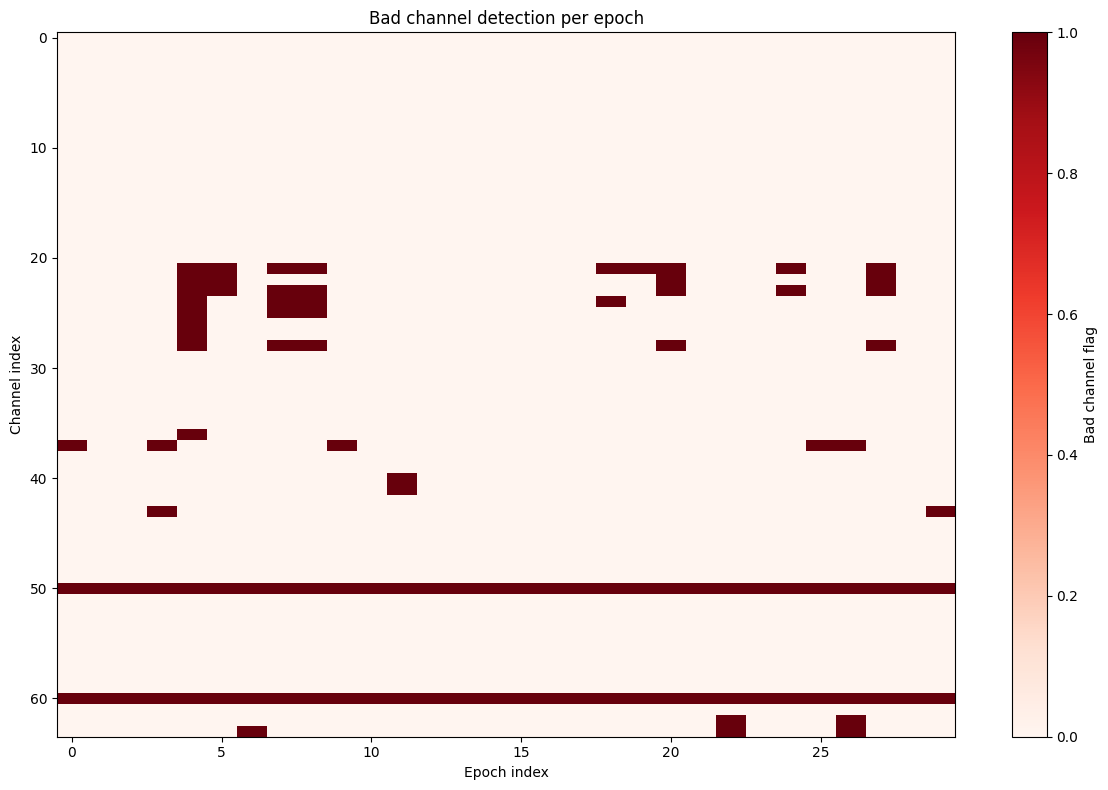

Saved: results_replacement_epochwise\bad_channel_epoch_heatmap.png


In [9]:
plt.figure(figsize=(12, 8))
plt.imshow(bad_matrix.T, aspect="auto", interpolation="nearest", cmap="Reds")
plt.xlabel("Epoch index")
plt.ylabel("Channel index")
plt.title("Bad channel detection per epoch")
plt.colorbar(label="Bad channel flag")
plt.tight_layout()
heatmap_path = OUTPUT_DIR / "bad_channel_epoch_heatmap.png"
plt.savefig(heatmap_path, dpi=200)
plt.show()

print("Saved:", heatmap_path)

## 10. Persistent Bad Channels from Epoch-Wise Detection

Epoch-wise detection is useful for local bad segments. For interpolation, however, it is safer to interpolate only channels that are bad repeatedly or structurally bad.

Here, a persistent bad channel is defined as a channel that is bad in more than 30% of epochs.

In [10]:
bad_fraction_per_channel = bad_matrix.mean(axis=0)

persistent_bad_channels = [
    epoch_ch_names[i]
    for i, frac in enumerate(bad_fraction_per_channel)
    if frac > 0.30
]

persistent_bad_summary = {
    epoch_ch_names[i]: float(bad_fraction_per_channel[i])
    for i in range(len(epoch_ch_names))
    if epoch_ch_names[i] in persistent_bad_channels
}

print("Persistent bad channels (>30% bad epochs):")
print(persistent_bad_channels)

with open(OUTPUT_DIR / "persistent_bad_channels.json", "w", encoding="utf-8") as f:
    json.dump(persistent_bad_summary, f, indent=2)

persistent_bad_summary

Persistent bad channels (>30% bad epochs):
['Pz..', 'O1..']


{'Pz..': 1.0, 'O1..': 1.0}

## 11. Bad-Channel Interpolation

This step interpolates structural/persistent bad channels. It also fixes montage-name mismatches in the EDF file.

Important distinction:

- **artifact-contaminated channels** may contain a blink, but are not necessarily broken electrodes
- **bad channels** are structurally unreliable, for example flat or extremely noisy

For interpolation, we use persistent bad channels from epoch-wise detection plus clearly structural global bad channels.

Structural global bads: ['Fp1.', 'Pz..', 'O1..']
Persistent epoch-wise bads: ['Pz..', 'O1..']
Combined bads selected for interpolation: ['Fp1', 'Pz', 'O1']
Valid bads for interpolation: ['Fp1', 'Pz', 'O1']
Skipped invalid-position bads: []
Bad channels before interpolation: ['Fp1', 'Pz', 'O1']
Bad channels after interpolation: []


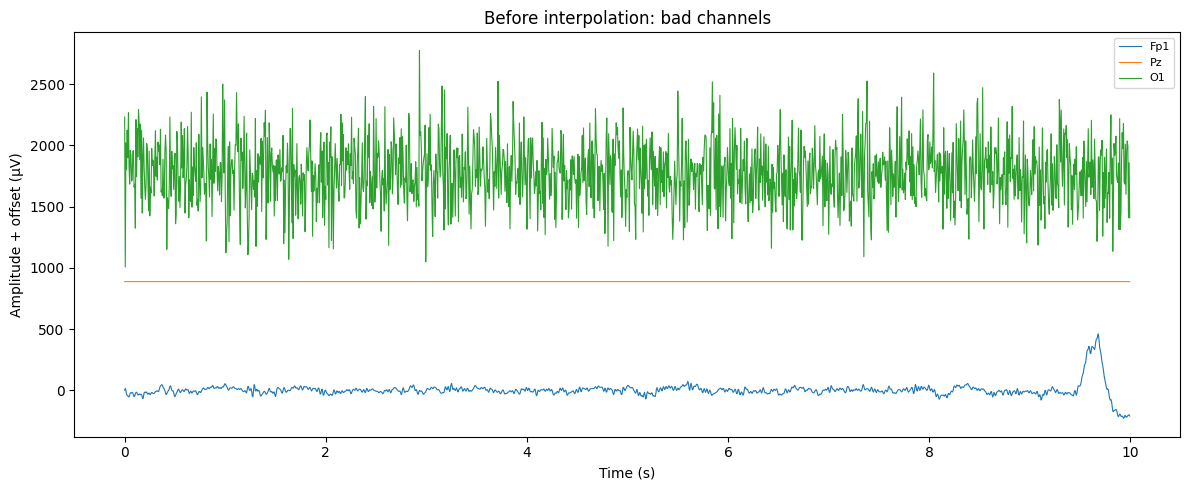

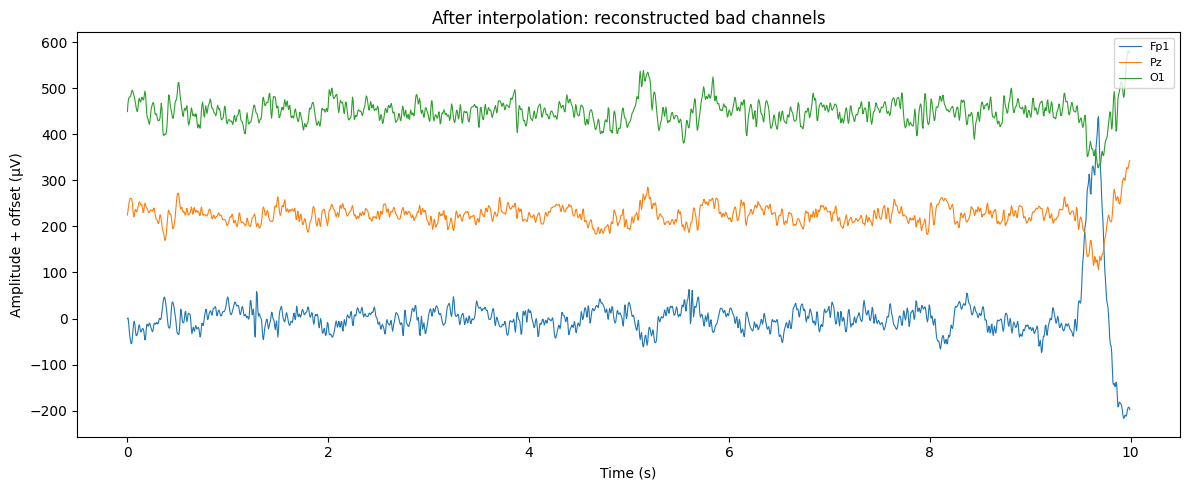

In [ ]:
def clean_channel_name(name):
    return name.replace(".", "")

montage = mne.channels.make_standard_montage("standard_1020")
montage_name_map = {name.lower(): name for name in montage.ch_names}


def to_montage_name(original_name):
    cleaned = clean_channel_name(original_name)
    return montage_name_map.get(cleaned.lower(), cleaned)


structural_global_bads = []
for row in metrics:
    if not row["bad"]:
        continue
    reason = row["reason"].lower()
    if (
        "flat" in reason
        or "very high std/noisy" in reason
        or "low correlation" in reason
    ):
        structural_global_bads.append(row["channel"])


combined_bads_original_names = list(dict.fromkeys(structural_global_bads + persistent_bad_channels))
combined_bads_montage_names = [to_montage_name(ch) for ch in combined_bads_original_names]
combined_bads_montage_names = list(dict.fromkeys(combined_bads_montage_names))

raw_for_interp = raw_artifact.copy()
rename_map = {ch: to_montage_name(ch) for ch in raw_for_interp.ch_names}
raw_for_interp.rename_channels(rename_map)
raw_for_interp.set_montage(montage, on_missing="ignore", verbose=False)

valid_bads = []
invalid_bads = []
for ch in combined_bads_montage_names:
    if ch not in raw_for_interp.ch_names:
        invalid_bads.append(ch)
        continue
    idx = raw_for_interp.ch_names.index(ch)
    loc = raw_for_interp.info["chs"][idx]["loc"][:3]
    if np.isfinite(loc).all():
        valid_bads.append(ch)
    else:
        invalid_bads.append(ch)

print("Structural global bads:", structural_global_bads)
print("Persistent epoch-wise bads:", persistent_bad_channels)
print("Combined bads selected for interpolation:", combined_bads_montage_names)
print("Valid bads for interpolation:", valid_bads)
print("Skipped invalid-position bads:", invalid_bads)

raw_for_interp.info["bads"] = valid_bads
print("Bad channels before interpolation:", raw_for_interp.info["bads"])

raw_interpolated = raw_for_interp.copy().interpolate_bads(
    reset_bads=True,
    on_bad_position="ignore",
    verbose=False,
)

print("Bad channels after interpolation:", raw_interpolated.info["bads"])

if valid_bads:
    plot_time_segment(raw_for_interp, "Before interpolation: bad channels", "07_before_interpolation.png", picks=valid_bads, duration=10)
    plot_time_segment(raw_interpolated, "After interpolation: reconstructed bad channels", "08_after_interpolation.png", picks=valid_bads, duration=10)
else:
    print("No valid structural/persistent bad channels available for interpolation.")

## 12. ICA Blink-Removal Example

ICA assumes that multichannel EEG is a mixture of hidden source components. Some components can represent brain activity, while others can represent artifacts such as eye blinks.

This example:

1. adds a synthetic blink to frontal channels
2. runs ICA
3. finds the component most correlated with the frontal blink signal
4. removes that component
5. compares frontal channels before and after ICA

Most blink-like ICA component: 0
Correlation with frontal blink signal: 0.8604427015414233


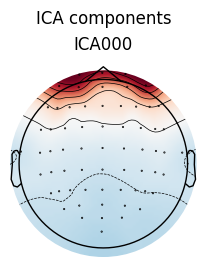

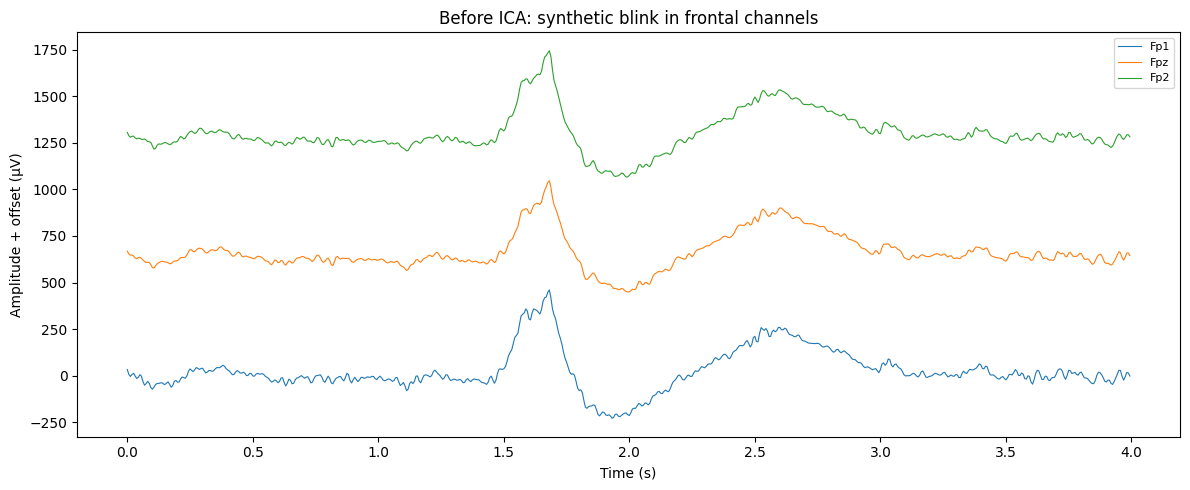

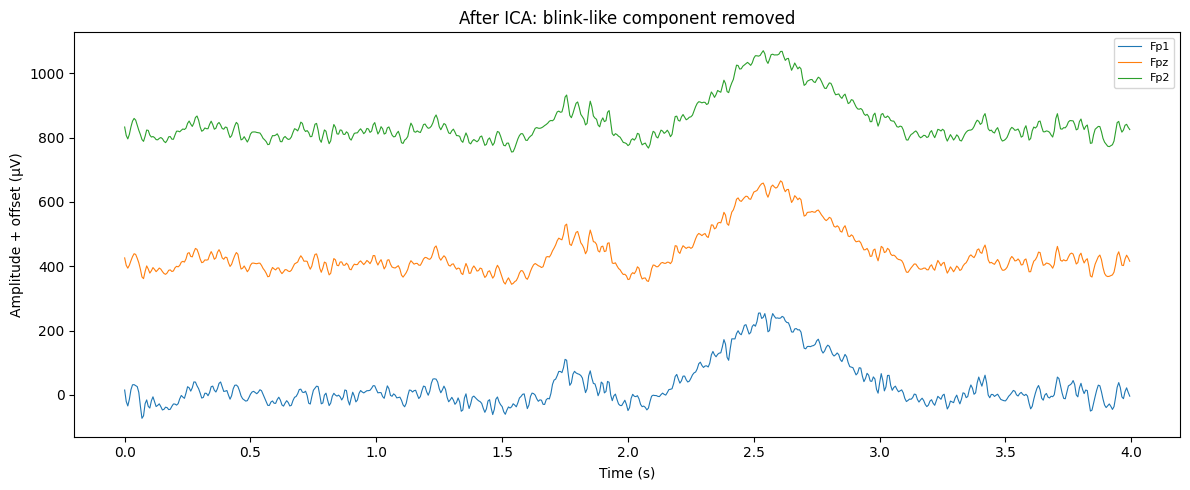

WindowsPath('results_replacement_epochwise/11_after_ica_blink.png')

In [12]:
raw_blink = add_synthetic_blink(raw_basic.copy(), onset=10.0, duration=1.2, amplitude_uv=220.0)

raw_blink_ica = raw_blink.copy()
raw_blink_ica.rename_channels({ch: to_montage_name(ch) for ch in raw_blink_ica.ch_names})
raw_blink_ica.set_montage(montage, on_missing="ignore", verbose=False)

ica = mne.preprocessing.ICA(
    n_components=20,
    random_state=42,
    max_iter="auto",
    method="fastica",
    verbose=False,
)
ica.fit(raw_blink_ica, picks="eeg", verbose=False)

frontal = [ch for ch in ["Fp1", "Fpz", "Fp2"] if ch in raw_blink_ica.ch_names]
frontal_signal = raw_blink_ica.copy().pick(frontal).get_data().mean(axis=0)
sources = ica.get_sources(raw_blink_ica).get_data()
correlations = np.array([np.corrcoef(src, frontal_signal)[0, 1] for src in sources])
blink_component = int(np.nanargmax(np.abs(correlations)))

print("Most blink-like ICA component:", blink_component)
print("Correlation with frontal blink signal:", correlations[blink_component])

try:
    fig = ica.plot_components(picks=[blink_component], show=False)
    if isinstance(fig, list):
        fig = fig[0]
    fig.savefig(OUTPUT_DIR / "09_blink_like_ica_component.png", dpi=200)
    plt.show()
except Exception as e:
    print("ICA component topography plot could not be created:", e)

raw_ica_clean = raw_blink_ica.copy()
ica.exclude = [blink_component]
ica.apply(raw_ica_clean, verbose=False)

plot_time_segment(raw_blink_ica, "Before ICA: synthetic blink in frontal channels", "10_before_ica_blink.png", picks=frontal, duration=4, start=8)
plot_time_segment(raw_ica_clean, "After ICA: blink-like component removed", "11_after_ica_blink.png", picks=frontal, duration=4, start=8)